# 생활폐기물은 어디서, 얼마나 버려지고 어떻게 처리될까

### - 인구 규모와 1인당 폐기물·재활용률의 지역 격차 분석 -

> **빅데이터 분석 수행평가** · 프로그래밍 기반 데이터 수집 및 시각화를 통한 심층 분석 저널리즘 기사 작성하기
> (          ) 고등학교 (   ) 반 (   ) 번 이름 (                  )

**과제 요구사항 체크리스트**

| # | 요구사항 | 이 노트북에서 |
|---|---------|--------------|
| 1 | 가설을 세우고 기사 주제 정하기 | 1번 항목 |
| 2 | 공공데이터 수집 + Pandas 전처리(결측치 제거 등) | 3 ~ 4번 항목 |
| 3 | matplotlib으로 그래프 4개 이상 | 5번 항목 (그래프 **5개**) |
| 4 | 시각화를 활용한 언론 기사(제목-전문-본문-결론) | 6번 항목 |

> 💡 **Google Colab에서 돌릴 분은 맨 아래 [부록] '구글 코랩에서 실행하는 법'을 먼저 읽어주세요.**
> 바꿔야 할 곳은 (1) 데이터 파일 업로드, (2) 한글 폰트 설치 두 군데뿐이고, 이 노트북은 두 환경 모두에서 그대로 돌아가도록 만들었습니다.

## 1. 가설 세우기와 기사 주제

**평소 궁금했던 현상**
"인구가 많은 도시일수록 쓰레기도 많이 나올 텐데, 그럼 1인당 버리는 양이나 재활용 잘하는 정도도 지역마다 다를까?"

**가설**
- **가설 1.** 시도별 생활폐기물 발생량은 인구 규모와 강한 양(+)의 상관관계를 가질 것이다.
- **가설 2.** 그러나 **1인당** 생활폐기물 발생량은 지역마다 큰 차이가 있을 것이다. (관광·산업 구조 영향)
- **가설 3.** 재활용률 역시 지역별 편차가 클 것이다.

**기사 주제**
> "인구가 쓰레기를 만든다? - 데이터로 본 17개 시도의 생활폐기물 민낯"

**사용 데이터 (공공데이터)**
1. `폐기물 발생량 및 처리현황_생활폐기물.xlsx` - 환경부/한국환경공단, 2024년 시도별 생활폐기물 발생·처리량
2. `202605_202605_주민등록인구및세대현황_월간.csv` - 행정안전부 주민등록인구통계, 2026년 5월 시도별 인구

> ⚠️ **분석의 한계**: 폐기물은 2024년 기준, 인구는 2026년 5월 기준이라 시점이 다릅니다. 1인당 지표는 '근삿값'으로 해석합니다. (실제 보고서라면 같은 연도로 맞춰야 함)

## 2. 라이브러리 불러오기 & 한글 폰트 설정

matplotlib은 기본 상태에서 한글이 □□□(네모)로 깨집니다. 아래 셀이 **실행 환경(맥/윈도우/Colab)을 자동으로 감지**해서 한글 폰트를 잡아줍니다.

In [1]:
# === [Colab 전용] 한글 폰트 설치 ===
# 로컬(맥/윈도우)에서는 아무 일도 일어나지 않으니 그냥 실행하고 넘어가면 됩니다.
import sys, subprocess
if 'google.colab' in sys.modules:
    print("Colab 감지 → 나눔폰트 설치 중...")
    subprocess.run(['apt-get', '-qq', 'install', '-y', 'fonts-nanum'], check=False)
    subprocess.run(['fc-cache', '-fv'], check=False, capture_output=True)
    print("설치 완료 ✅")
else:
    print("로컬 환경 → 폰트 설치 셀 건너뜀")

로컬 환경 → 폰트 설치 셀 건너뜀


In [2]:
import platform
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

warnings.filterwarnings('ignore')   # 분석에 무관한 경고 메시지 숨기기

# ----- 운영체제별 한글 폰트 자동 설정 -----
system = platform.system()
if system == 'Darwin':            # macOS (로컬)
    rcParams['font.family'] = 'AppleGothic'
elif system == 'Windows':         # Windows (로컬)
    rcParams['font.family'] = 'Malgun Gothic'
else:                             # Linux / Google Colab
    nanum = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    try:
        font_manager.fontManager.addfont(nanum)
        rcParams['font.family'] = 'NanumGothic'
    except Exception:
        rcParams['font.family'] = 'DejaVu Sans'   # 폰트가 없으면 영어 폰트로 대체

rcParams['axes.unicode_minus'] = False            # 마이너스(-) 깨짐 방지
print("폰트 설정 완료:", rcParams['font.family'])

폰트 설정 완료: ['AppleGothic']


## 3. 데이터 불러오기

> 📁 **파일 경로** - 아래 두 변수만 환경에 맞게 바꾸면 됩니다.
> - **로컬**: 노트북과 데이터 파일을 같은 폴더에 두면 그대로 실행됩니다.
> - **Colab**: 파일을 업로드한 뒤 보통 그대로 두면 됩니다. (부록 참고)

In [3]:
WASTE_PATH = "폐기물 발생량 및 처리현황_생활폐기물.xlsx"
POP_PATH   = "202605_202605_주민등록인구및세대현황_월간.csv"

# 1) 생활폐기물 엑셀: 맨 위 6줄이 다단 헤더라서 header=None으로 통째로 읽는다
waste_raw = pd.read_excel(WASTE_PATH, sheet_name=0, header=None)

# 2) 주민등록인구 CSV: 한글 윈도우에서 저장돼 cp949 인코딩
pop_raw = pd.read_csv(POP_PATH, encoding='cp949')

print("폐기물 원본 shape:", waste_raw.shape)
print("인구 원본 shape  :", pop_raw.shape)
waste_raw.head(8)

폐기물 원본 shape: (763, 12)
인구 원본 shape  : (18, 7)


,0,1,2,3,4,5,6,7,8,9,10,11
0,No,분류,분류,분류,분류,2024년,2024년,2024년,2024년,2024년,2024년,2024년
1,No,분류,분류,분류,분류,발생량,처리량,처리량,처리량,처리량,처리량,처리량
2,No,분류,분류,분류,분류,발생량,재활용,재활용,재활용,소각,매립,기타
3,No,분류,분류,분류,분류,발생량,소계,물질재활용,에너지회수,소각,매립,기타
4,No,분류,분류,분류,분류,톤/년,톤/년,톤/년,톤/년,톤/년,톤/년,톤/년
5,No,분류,분류,분류,분류,원자료,원자료,원자료,원자료,원자료,원자료,원자료
6,1,전국,합계,합계,합계,"17,045,141.1","10,185,130.1","7,968,876.6","2,216,253.5","5,091,733.4","1,681,451.6","86,826"
7,2,전국,종량제방식 등 혼합배출,소계,소계,"8,430,183.8","1,850,143.2","729,841.2","1,120,301.9","4,918,079.2","1,616,447.2","45,514.3"


## 4. 데이터 전처리 (Pandas)

엑셀이 사람이 보기 좋게 병합셀·다단 헤더로 되어 있어서 바로 분석할 수 없습니다. 다음 순서로 정리합니다.

1. 컬럼 이름 직접 지정 (다단 헤더 → 단일 헤더)
2. 본문(7번째 행부터)만 남기기
3. 시도별 **합계 행**만 추출 (배출방식=품목=합계)
4. 숫자에 섞인 쉼표(`,`) 제거 후 숫자형으로 변환
5. 인구 데이터의 지역명을 폐기물 데이터와 똑같이 통일 (예: `서울특별시` → `서울`)
6. **결측치(NaN) 확인 및 제거**
7. 두 데이터를 '지역' 기준으로 병합

In [4]:
# ----- 4-1. 폐기물 데이터 전처리 -----
cols = ['No','지역','배출방식','대분류','품목',
        '발생량','재활용','물질재활용','에너지회수','소각','매립','기타']
waste_raw.columns = cols

body = waste_raw.iloc[6:].copy()                 # 본문만 (위 6줄은 헤더 설명)

# 시도별 '총합계' 행만 추출
mask = (body['배출방식']=='합계') & (body['대분류']=='합계') & (body['품목']=='합계')
waste = body[mask].copy()

# 숫자 컬럼: 쉼표 제거 후 float 변환
num_cols = ['발생량','재활용','소각','매립','기타']
for c in num_cols:
    waste[c] = waste[c].astype(str).str.replace(',', '', regex=False).astype(float)

waste = waste[['지역'] + num_cols].reset_index(drop=True)
print("시도별 폐기물 데이터:")
waste

시도별 폐기물 데이터:


,지역,발생량,재활용,소각,매립,기타
0,전국,17045141.1,10185130.1,5091733.4,1681451.6,86826.0
1,서울,2893575.5,1784403.2,894326.6,213433.8,1412.3
2,부산,914513.2,763449.1,124910.9,25297.9,855.3
3,대구,755965.7,462775.6,90677.3,202229.8,283.0
4,인천,860321.3,538543.6,245418.6,76295.4,63.6
5,광주,469198.8,414975.4,12307.5,35201.0,6714.9
6,대전,487592.8,332814.7,93414.7,58653.9,2709.5
7,울산,347921.2,168072.2,157058.7,22790.2,0.0
8,세종,108101.6,59512.9,48588.7,0.0,0.0
9,경기,4337886.0,2707884.4,1316580.4,272661.9,40759.1


In [5]:
# ----- 4-2. 인구 데이터 전처리 -----
import re
pop = pop_raw.copy()
pop.columns = ['행정구역','총인구수','세대수','세대당인구','남자','여자','남여비율']

# '서울특별시  (1100000000)' → '서울' 로 통일
name_map = {
    '서울특별시':'서울','부산광역시':'부산','대구광역시':'대구','인천광역시':'인천',
    '광주광역시':'광주','대전광역시':'대전','울산광역시':'울산','세종특별자치시':'세종',
    '경기도':'경기','강원특별자치도':'강원','강원도':'강원','충청북도':'충북','충청남도':'충남',
    '전북특별자치도':'전북','전라북도':'전북','전라남도':'전남','경상북도':'경북',
    '경상남도':'경남','제주특별자치도':'제주','전국':'전국',
}
def to_short(name):
    name = re.sub(r'\s*\(\d+\)', '', str(name)).strip()   # 괄호 코드 제거
    return name_map.get(name, name)

pop['지역'] = pop['행정구역'].apply(to_short)
pop['총인구수'] = pop['총인구수'].astype(str).str.replace(',', '', regex=False).astype(int)
pop = pop[['지역','총인구수']]
print("시도별 인구 데이터:")
pop.head()

시도별 인구 데이터:


,지역,총인구수
0,전국,51095330
1,서울,9295082
2,부산,3234293
3,대구,2349305
4,인천,3058623


In [6]:
# ----- 4-3. 결측치 확인 & 제거, 그리고 병합 -----
print("[결측치 개수] 폐기물\n", waste.isnull().sum(), "\n")
print("[결측치 개수] 인구\n", pop.isnull().sum(), "\n")

# 혹시 모를 결측치 제거
waste = waste.dropna()
pop   = pop.dropna()

# '지역' 기준으로 병합 (전국 행은 분석에서 제외하고 따로 보관)
nation = waste[waste['지역']=='전국'].iloc[0]      # 전국 합계는 따로 보관
df = waste[waste['지역']!='전국'].merge(pop, on='지역', how='inner')

# 파생 변수: 1인당 발생량(kg/년), 재활용률(%)
df['1인당발생량'] = df['발생량'] * 1000 / df['총인구수']   # 톤 → kg
df['재활용률']   = df['재활용'] / df['발생량'] * 100

print("병합 후 시도 수:", len(df))
df.sort_values('발생량', ascending=False).reset_index(drop=True)

[결측치 개수] 폐기물
 지역     0
발생량    0
재활용    0
소각     0
매립     0
기타     0
dtype: int64 

[결측치 개수] 인구
 지역      0
총인구수    0
dtype: int64 

병합 후 시도 수: 17


,지역,발생량,재활용,소각,매립,기타,총인구수,1인당발생량,재활용률
0,경기,4337886.0,2707884.4,1316580.4,272661.9,40759.1,13755126,315.365050,62.424056
1,서울,2893575.5,1784403.2,894326.6,213433.8,1412.3,9295082,311.301772,61.667760
2,경남,1130858.6,547056.7,378121.2,205680.7,0.0,3196632,353.765651,48.375341
3,경북,940672.7,520882.6,335198.7,82120.0,2471.4,2496706,376.765506,55.373415
4,부산,914513.2,763449.1,124910.9,25297.9,855.3,3234293,282.755211,83.481474
5,인천,860321.3,538543.6,245418.6,76295.4,63.6,3058623,281.277326,62.597962
6,충남,811484.8,333032.0,372996.4,105455.4,1.0,2138517,379.461468,41.039832
7,대구,755965.7,462775.6,90677.3,202229.8,283.0,2349305,321.782697,61.216481
8,전남,685678.2,331740.0,180579.2,164676.5,8682.5,1774082,386.497467,48.381296
9,전북,621947.5,322774.7,245605.7,53148.9,418.2,1719420,361.719359,51.897419


## 5. 데이터 시각화 (matplotlib 그래프 5개)

| 그래프 | 종류 | 무엇을 보는가 |
|--------|------|--------------|
| ① 시도별 발생량 | 가로 막대 | 어디서 제일 많이 버리나 |
| ② 인구 vs 발생량 | 산점도 + 추세선 | **가설 1** 검증 (상관관계) |
| ③ 1인당 발생량 | 막대 + 평균선 | **가설 2** 검증 (1인당 격차) |
| ④ 전국 처리방법 구성 | 파이 | 재활용·소각·매립 비율 |
| ⑤ 시도별 재활용률 | 막대 + 평균선 | **가설 3** 검증 (재활용 격차) |

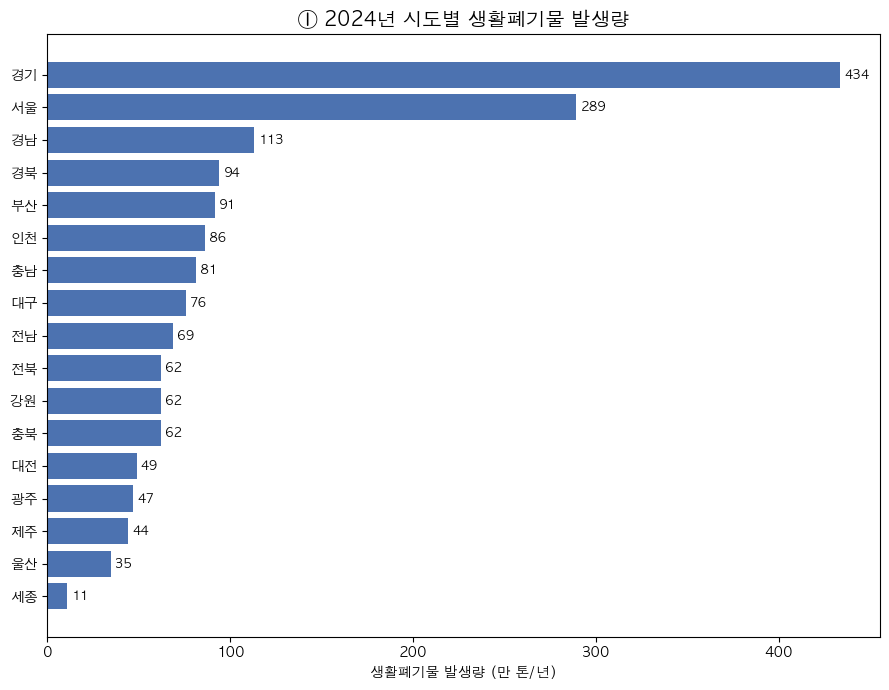

In [7]:
# ----- 그래프 ① 시도별 생활폐기물 발생량 (가로 막대) -----
d = df.sort_values('발생량')
plt.figure(figsize=(9, 7))
bars = plt.barh(d['지역'], d['발생량']/10000, color='#4C72B0')
plt.xlabel('생활폐기물 발생량 (만 톤/년)')
plt.title('① 2024년 시도별 생활폐기물 발생량', fontsize=14, fontweight='bold')
plt.bar_label(bars, fmt='%.0f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

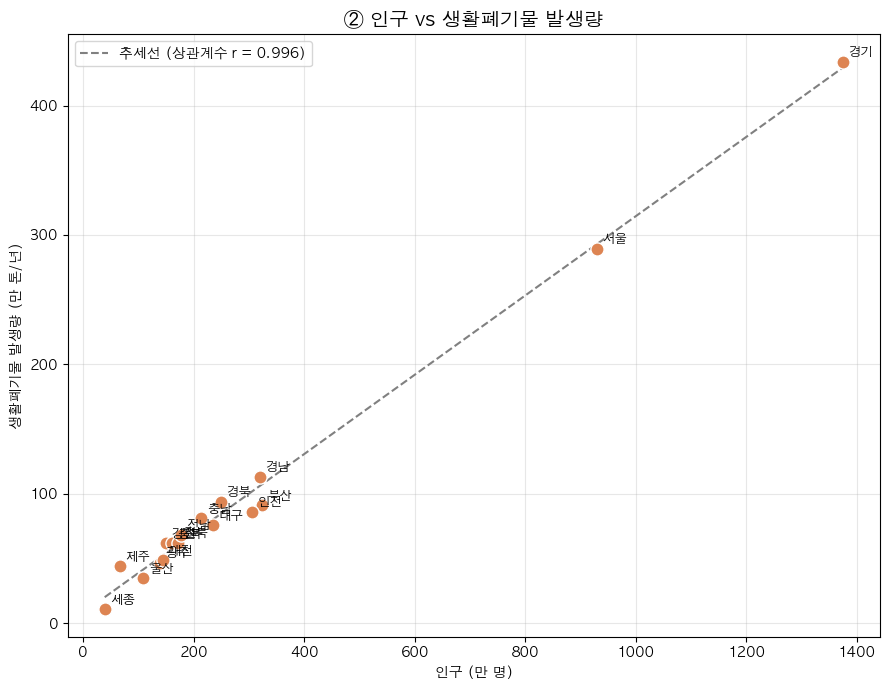

인구-발생량 상관계수 r = 0.996


In [8]:
# ----- 그래프 ② 인구 vs 발생량 산점도 + 추세선 (가설 1) -----
x = df['총인구수']/10000      # 만 명
y = df['발생량']/10000        # 만 톤
corr = df['총인구수'].corr(df['발생량'])

plt.figure(figsize=(9, 7))
plt.scatter(x, y, s=90, color='#DD8452', edgecolor='white', zorder=3)
for _, r in df.iterrows():
    plt.annotate(r['지역'], (r['총인구수']/10000, r['발생량']/10000),
                 fontsize=9, xytext=(4, 4), textcoords='offset points')

# 추세선 (1차 회귀)
a, b = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 100)
plt.plot(xs, a*xs + b, '--', color='gray', label=f'추세선 (상관계수 r = {corr:.3f})')

plt.xlabel('인구 (만 명)')
plt.ylabel('생활폐기물 발생량 (만 톤/년)')
plt.title('② 인구 vs 생활폐기물 발생량', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"인구-발생량 상관계수 r = {corr:.3f}")

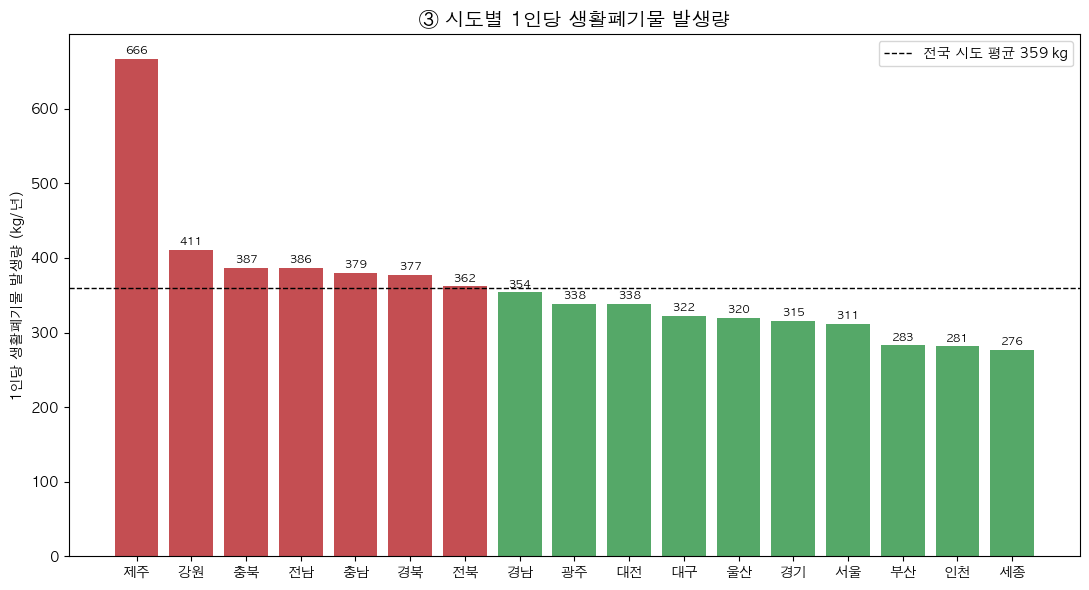

In [9]:
# ----- 그래프 ③ 시도별 1인당 발생량 (가설 2) -----
d = df.sort_values('1인당발생량', ascending=False)
avg = df['1인당발생량'].mean()

plt.figure(figsize=(11, 6))
colors = ['#C44E52' if v > avg else '#55A868' for v in d['1인당발생량']]
bars = plt.bar(d['지역'], d['1인당발생량'], color=colors)
plt.axhline(avg, color='black', linestyle='--', linewidth=1,
            label=f'전국 시도 평균 {avg:.0f} kg')
plt.ylabel('1인당 생활폐기물 발생량 (kg/년)')
plt.title('③ 시도별 1인당 생활폐기물 발생량', fontsize=14, fontweight='bold')
plt.bar_label(bars, fmt='%.0f', padding=2, fontsize=8)
plt.legend()
plt.tight_layout()
plt.show()

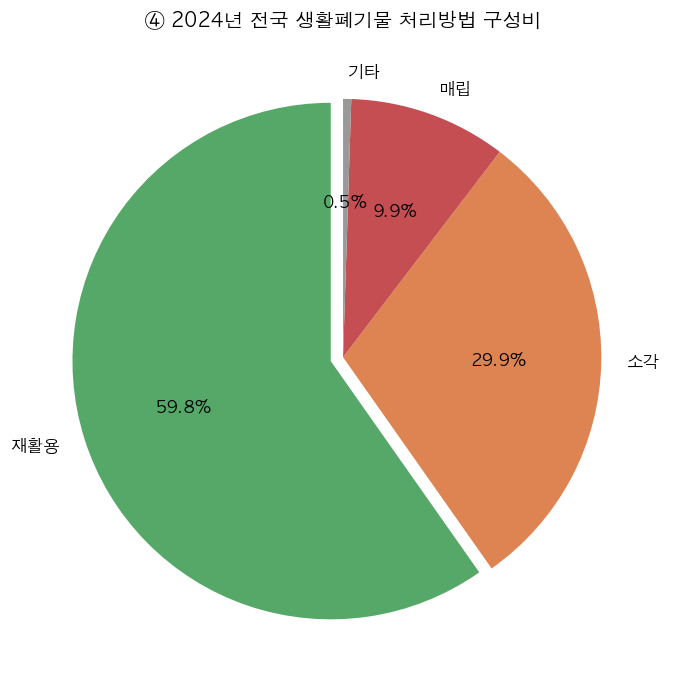

In [10]:
# ----- 그래프 ④ 전국 생활폐기물 처리방법 구성비 (파이) -----
labels = ['재활용', '소각', '매립', '기타']
sizes  = [nation['재활용'], nation['소각'], nation['매립'], nation['기타']]
colors4 = ['#55A868', '#DD8452', '#C44E52', '#999999']
explode = [0.05, 0, 0, 0]

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct='%.1f%%', startangle=90,
        colors=colors4, explode=explode, textprops={'fontsize': 12})
plt.title('④ 2024년 전국 생활폐기물 처리방법 구성비', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

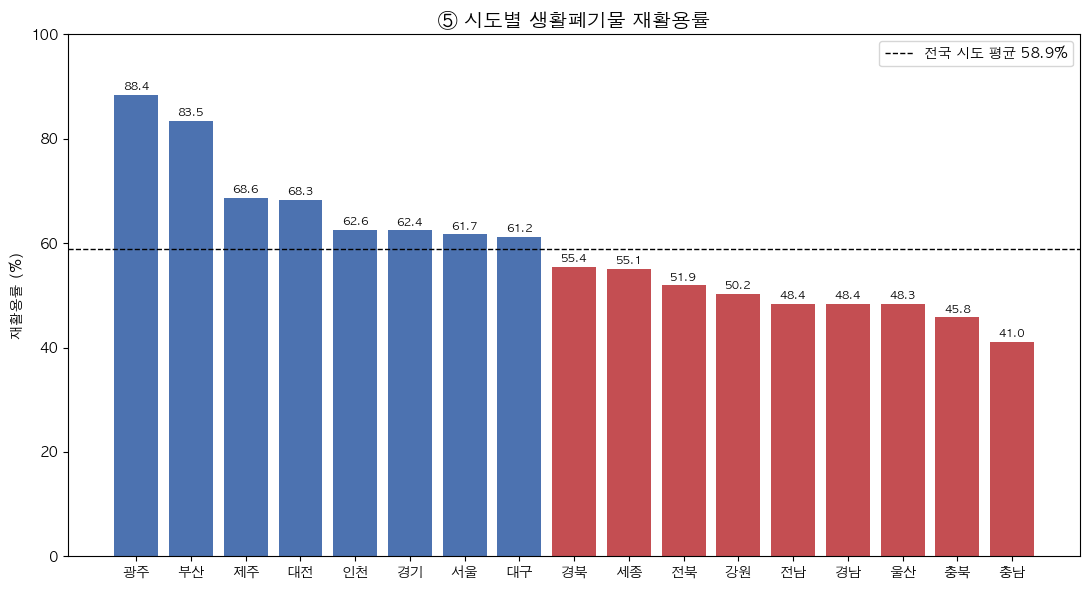

In [11]:
# ----- 그래프 ⑤ 시도별 재활용률 (가설 3) -----
d = df.sort_values('재활용률', ascending=False)
avg_r = df['재활용률'].mean()

plt.figure(figsize=(11, 6))
colors = ['#4C72B0' if v >= avg_r else '#C44E52' for v in d['재활용률']]
bars = plt.bar(d['지역'], d['재활용률'], color=colors)
plt.axhline(avg_r, color='black', linestyle='--', linewidth=1,
            label=f'전국 시도 평균 {avg_r:.1f}%')
plt.ylabel('재활용률 (%)')
plt.title('⑤ 시도별 생활폐기물 재활용률', fontsize=14, fontweight='bold')
plt.bar_label(bars, fmt='%.1f', padding=2, fontsize=8)
plt.legend()
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## 6. 데이터 저널리즘 기사

---

### 인구가 쓰레기를 만든다? - 데이터로 본 17개 시도 생활폐기물의 민낯

**[전문]** 2024년 우리나라에서 발생한 생활폐기물은 약 **1,705만 톤**에 달했다. 인구가 많은 곳에서 쓰레기도 많이 나온다는 통념은 데이터로 거의 완벽하게 확인됐다. 그러나 '1인당' 관점으로 시선을 돌리자 전혀 다른 그림이 펼쳐졌다. 같은 국민인데도 사는 지역에 따라 1인당 배출량은 **2배 이상**, 재활용률은 **40%대에서 90% 가까이**까지 벌어졌다.

**[본문]**

먼저 가설대로 **인구와 폐기물 발생량은 거의 일직선 위에 놓였다.** 17개 시도의 인구와 생활폐기물 발생량의 상관계수는 **0.996**으로, 통계적으로 '거의 완벽한 비례'에 해당한다(그래프 ②). 발생량 1위는 경기(약 434만 톤), 2위는 서울(약 289만 톤)로 인구 순위와 그대로 맞아떨어졌다(그래프 ①). 인구가 많을수록 쓰레기가 많다는 상식은 데이터로 분명히 뒷받침된다.

하지만 **'한 사람이 얼마나 버리는가'를 보면 이야기가 달라진다.** 1인당 발생량 1위는 **제주(약 666kg/년)** 로, 꼴찌인 **세종(약 276kg/년)** 의 **2.4배**에 달했다(그래프 ③). 인구가 적은 제주가 1인당 배출량 1위라는 사실은, 연간 수백만 명이 다녀가는 **관광객이 만든 쓰레기가 주민 수로 나뉘면서** 1인당 수치를 끌어올린 것으로 풀이된다. 즉 통계의 '분모'를 무엇으로 두느냐에 따라 같은 지역이 정반대로 보일 수 있다.

**처리 방식**에서도 개선과 과제가 함께 드러났다. 전국 생활폐기물의 **59.8%가 재활용**됐고, 소각 29.9%, 매립 9.9% 순이었다(그래프 ④). 매립 비율이 10% 아래로 내려온 것은 긍정적이지만, 여전히 발생량의 30% 가까이가 태워지고 있다. 더 큰 문제는 **지역 격차**다. 재활용률 1위 **광주(88.4%)** 와 최하위 **충남(41.0%)** 의 차이는 무려 **47%포인트**에 이른다(그래프 ⑤). 같은 제도 아래에서도 지자체의 분리배출 인프라와 정책에 따라 결과가 크게 갈린다는 의미다.

**[결론]**

데이터는 두 가지를 분명히 말한다. 첫째, **총량은 인구가 결정한다.** 따라서 대도시권의 폐기물 정책이 국가 전체 성패를 좌우한다. 둘째, 그러나 **'잘 버리고 잘 처리하는' 능력은 인구와 무관하며 지역마다 천차만별이다.** 제주처럼 유동인구가 많은 지역은 1인당 지표를, 충남처럼 재활용률이 낮은 지역은 처리 인프라를 각각 다른 처방으로 접근해야 한다. 쓰레기 문제에 '전국 단일 해법'은 없다. 데이터가 보여준 지역별 민낯을 직시하는 것이 첫걸음이다.

> *데이터 출처: 환경부·한국환경공단 「생활폐기물 발생 및 처리현황」(2024), 행정안전부 「주민등록인구통계」(2026.5).*
> *분석 도구: Python (Pandas, Matplotlib). 인구는 2026년 5월 기준으로, 1인당 지표는 근삿값임.*

---

## [부록] 구글 코랩(Google Colab)에서 실행하는 법

이 노트북은 **로컬(맥/윈도우)과 Colab 모두에서 수정 없이 돌아가도록** 만들었습니다. Colab에서는 아래 두 가지만 신경 쓰면 됩니다.

### ✅ 1단계 - 데이터 파일 업로드
Colab은 내 컴퓨터의 파일을 자동으로 못 봅니다. 두 가지 방법 중 하나로 올리세요.

**(A) 가장 간단 - 직접 업로드**
왼쪽 사이드바의 📁 **파일** 아이콘 → **업로드** 버튼으로 아래 두 파일을 올립니다.
- `폐기물 발생량 및 처리현황_생활폐기물.xlsx`
- `202605_202605_주민등록인구및세대현황_월간.csv`

또는 코드로 업로드 창 띄우기 (새 코드 셀에 붙여넣고 실행):
```python
from google.colab import files
uploaded = files.upload()   # 창이 뜨면 위 두 파일 선택
```
> 업로드한 파일은 현재 폴더에 그대로 저장되므로 **`WASTE_PATH`, `POP_PATH`는 바꿀 필요가 없습니다.**

**(B) 구글 드라이브에 넣고 마운트** (파일을 매번 안 올리고 싶을 때)
```python
from google.colab import drive
drive.mount('/content/drive')
```
드라이브의 `내 드라이브/data/` 폴더에 파일을 뒀다면 3번 셀의 경로를 이렇게 바꿉니다.
```python
WASTE_PATH = "/content/drive/MyDrive/data/폐기물 발생량 및 처리현황_생활폐기물.xlsx"
POP_PATH   = "/content/drive/MyDrive/data/202605_202605_주민등록인구및세대현황_월간.csv"
```

### ✅ 2단계 - 한글 폰트 (이미 자동 처리됨)
2번 항목 첫 번째 코드 셀이 **Colab을 자동 감지해서 나눔폰트를 설치**합니다. 그냥 위에서부터 순서대로 실행하면 됩니다.
혹시 그래프 한글이 □□로 깨지면 **[런타임] → [세션 다시 시작]** 후 위에서부터 다시 실행하세요. (폰트 설치 후 한 번만 재시작하면 됩니다.)

### ✅ 3단계 - 라이브러리
pandas, numpy, matplotlib은 Colab에 **기본 설치**되어 있어 `pip install`이 필요 없습니다.

---

### 요약: 로컬 ↔ Colab 차이

| 구분 | 로컬 (지금 이대로) | Google Colab |
|------|-------------------|--------------|
| 데이터 파일 | 노트북과 같은 폴더에 두기 | 📁 업로드 or 드라이브 마운트 |
| 한글 폰트 | AppleGothic / Malgun Gothic 자동 | 나눔폰트 자동 설치 (셀이 알아서 함) |
| 라이브러리 | 설치돼 있어야 함 | 기본 제공 |
| 파일 경로 | 그대로 | (A)업로드면 그대로 / (B)드라이브면 경로 수정 |